# ANALYSIS ON CAR COLOURS USAGES

In this analysis, the main topic will focus on how car colours trends changed in 3 to 5 years and how gender impacts to the car colours. With our analysis, it can be beneficial to car companies to evaluate the future changes based on the past 5 years data and prepare for the production line or promote the sales accordingly.

To clarify more in details, first finding will related to the top 5 car colours trends of 2020 and 2022 based on our sampling data from University of Bath students' vehicles and compare back to the top 5 car colours in 2017 with what we have found in [BBC News: What was the UK's favourite new car colour in 2017?](https://www.bbc.co.uk/news/uk-42683492) (BBC News, 2018). We will see whether which colour keeps remaining in the same rank place or going up/down in the rank, including with the percentage of usage to see whether how the usage of each colour in these top 5 colours are distributed.

And another finding will be analyzed based on 2022 data only by finding the relationship between the gender of the driver, which we will assume them as a car owner, and the colour of the car that they used to see whether what colour is the most popular one between each gender.

**Notes:** 

*1. Due to our wide range of the vehicle types, only cars and vans will be focused with 2 reasons why. First, we will try not go far beyond than the BBC's scope of exploration as it clearly stated in the title that it is a car colour. With that said, motorcycle and bicycle will be dropped from this focus. On the other hand, a colour of the other vehicles might be forced by some rules which the owner of the vehicle did not choose its colour from their preferences and it will mislead this analysis if they have been included i.e. company rules or ads on the lorry, govenment rules on the bus or taxi.*

*2. Acknowledged that the first and second findings should have the same dataset so that we could connect between 2 findings whether those usage percentages in each colour from the top 5 car colours trends in 2022 has been mostly selected from which gender. However, due to the limitation of this data collection that not every collectors, who collected car colours, collected the driver's gender or vice versa, we will pretend that the data we have for the finding 2 are the same data set with finding 1 to just show whether what we can analyse from this type of data collection only.*

**Reference:**

BCC News, 2018. What was the UK's favourite new car colour in 2017? [Online]. Available from: [https://www.bbc.co.uk/news/uk-42683492](https://www.bbc.co.uk/news/uk-42683492) [Accessed 27 October 2022].

### Stage 1: Clean up raw data from 2022

In this stage, the intention is to clean up data for consistency and combine those files into a single raw dataset which can be used for the analysis later on. Cleaning up data will be done by re-formatting data, dropping a row that contains the incorrect format data as it will be treated as the invalid data, remove null row and combine those columns with the same objective. The correct format of each column will be defined follows the instucton of Task 1. 

To clarify more, the below issues will be resolved:

1. Incorrect date format
    * Target: DD-MM-YYYY
    * How to resolve: The pandas.to_datetime will be used to resolve this issue. Most of the dates will be re-formatted automatically by using 'infer_datetime_format = True' if they were written in the format that the python can detect them as date type. However, there are dates which were written as DD-MMM only (year is missing), so these dates will be re-formatted and add 2022 (current year) manually in code.
<br><br>
2. Incorrect time format
    * Target: hh:mmam
    * How to resolve: There are 2 main steps to resolve this issue, the time format will be resolved first and rounding up time to nearest 5 minute will be resolved after that. Since the time needs to be rounded, they will be handled as float type with 2 decimals instead of time type.
<br><br>
3. Incorrect occupancy format
    * Target: Bus with percentage and others without percentage.
    * How to resolve: Data will be separated by type of vehicle and tackled differently. The bus type with out percentage sign (%) will be dropped as it could not be verified whether the collector intended to collect it by counting people inside that bus, especially for the small number which would be able to count, or roughly estimating them as percentage but forget to add %. For the other types, data will be set the maximum capacity to 8 which should cover the capacity of a van. Data that capacity exceeds the maximum limit will be dropped to remove the capacity that the collector intended to write as percentage but forget to add %, as well as the data with % which will be dropped too, with the reason that they could not be converted back due to the maximum capacity of each collector might not be the same value i.e. some people collected car as maximum capacity of 4 but some people collected it as maximum capacity of 5.
<br><br>
4. Used double quote as value
    * Target: Get rid of double quotes and replace them with the data it supposed to be
    * How to resolve: Replacing double quotes with NaN and fill down the data by using '.ffill'
<br><br>
5. Header and data are not matching together
    * Target: Maintain type and capacity in the correct columns
    * How to resolve: As this issue is caused by filling out the data in the incorrect columns, switch them back will be the solution. Data will be search for the % in the type column and swith it back if there is any in that dataframe before merging with other files.
<br><br>
6. Time out of range
    * Target: Data collected within 8.00am to 11.00am only
    * How to resolve: Those data that has been collected out of this time range will be dropped.
<br><br>
7. File with title row and different delimiter
    * Target: File with title should be read and combined with others.
    * How to resolve: There are 2 issues in this file that must be handled, the title row and the different delimiter. Once there is a title row, data will be read into 1 single column as it normally detects the first row as a header, so this behaviour will be used as a validator whether which file has a title row. And as checked, this file has 2 title rows which a pandas.read_csv() needs to skip and use the 3rd row as headers instead. Also, the delimiter needs to be indicated so that python will know and separate the column from them. 
<br><br>
7. Unintended space and align the letter case
    * Target: No unintended leading or trailing space in both data and header.
    * How to resolve: Using the str.strip() to remove the space and set the header to be all uppercase and all lowercase for data to prevent the case sensitive.
<br><br>
8. Align the column name and vehicle type
    * Target: Column name should be align and be able to merge and vehicle type should be align in the writting format i.e. car and cars.
    * How to resolve: Set up the dictionary and replace it as much as possible.
<br><br>
9. Align the data with the same objective
    * Target: Merge the same type of data
    * How to resolve: Merge columns with the same objective and align the values in those columns to reduce the number of columns and easy to analyze. Only the provided data will be aligned i.e. bicycle in some files are collected as electric bicycle and some are not, so the data will be kept as blank in those rows that related information was not provided as it could not be assumed that all bicycles are electric or all of them are manual.
<br><br>
10. Remove duplicates
    * Target: Only 1 set of data could be collected at the same date and time
    * How to resolve: Validate duplicate date from date, time, direction, and source file name as keys. Choose to keep the one with analysis keys (driver's gender and vehicle's colour) if exists. Otherwise, keep the one with most records in a period of 5 mins.

The final result of this stage should be a cleaned raw dataset which is ready to be analyzed. This raw dataset will be exported as a CSV file once done.

#### Importing the libraries
Starting from importing the libraries that will be used in this Jupyter file.

In [3]:
# Import related libraries
import glob
import matplotlib.pyplot
import numpy
import pandas

#### Defining functions

Due to the format of time is not be converted to the time type, so it needs to be treated as a string, or numeric when we split off the 'am'. That is the reason why these functions have been defined. The first one will be used for formatting the time into the correct format which is the hh.mm with 'am' or 'pm' in the end and the second is used for rounding up time accordingly. In these 2 functions, the out of range data still be handled. 

In [4]:
def format_time(time):
    
    # Initial declare time unit as AM based on task 1 instruction to collect the data before 11AM
    time_unit = 'am'
    
    # Split AM/PM out before re-calculating time
    if ('am' in time) | ('pm' in time):
        time_number = time[:-2]
        time_unit = time[-2:]
    else:
        time_number = time
    
    # To make sure that every row has the same format
    if (time_number.count('.') > 1):
        time_number = str(time_number.split('.')[0]) + '.' + str(time_number.split('.')[1])
    elif (time_number.count('.') < 1):
        time_number = time_number + '.00'
    else:
        pass
    
    # Concatenate back into the correct format
    time = str(format(float(time_number), '.2f')) + time_unit
    
    return time

def round_up_time(time):
    
    # Split AM/PM out before re-calculating time
    time_number = time[:-2]
    time_unit = time[-2:]
    
    # Get hr and min separately
    time_hr = time_number.split('.')[0]
    time_min = time_number.split('.')[1]
    
    # Check if it needs to change the time unit of not i.e. 11.55 to 11.59 am/pm which will be rounded to 12.00pm or 0.00am accordingly
    flag_changed = False
    if (int(time_hr) == 11) & (int(time_min) > 55):
        if time_unit == 'am':
            time_unit = 'pm'
            flag_changed = True
        else:
            time_unit = 'am'
            flag_changed = True
    
    # Round up to nearest 5-min
    if ((int(time_min) % 10) > 0) & ((int(time_min) % 10) < 5):
        time_min = (((int(time_min)) // 10) * 10) + 5
    elif ((int(time_min) % 10) > 5) & ((int(time_min) % 10) <= 9):
        time_min = (((int(time_min)) // 10) * 10) + 10
    else:
        pass
    
    # Handle min of 56-59 to round to the next hr instead, not 60 
    if time_min == 60:
        time_min = 0
        time_hr =  int(time_hr) + 1
    
    # Apply the change to hr = 12 when unit change i.e. 11.55 to 11.59 am/pm which will be rounded to 12.00pm or 0.00am accordingly
    if ((time_hr == 12) & (flag_changed == True)):
        if time_unit == 'am':
            time_hr = 0
    
    # Concatenate back to the correct format
    time_number = str(time_hr) + '.' + str(time_min)
    time = str(format(float(time_number), '.2f')) + time_unit
    
    return time

#### Processing data

Now, it is the time to begin processing the data. Starting from reading all CSV files from a folder, resolve the above issues, export as CSV file and print out the data table to show as a result.

In [5]:
# Work with 2022 data

# Declare variables, import files and cleaning date column

#--------------------------------------------------------------------------------------------------------------------

# Declare initial values
raw_data_2022 = pandas.DataFrame([])
path_2022 = '/Users/rasitapkr/Documents/MSc Data Science/Applied Data Science/Coursework/Data/csv_data_2022/'
path_export_raw_data_2022 = '/Users/rasitapkr/Documents/MSc Data Science/Applied Data Science/Coursework/Data/raw_data_2022.csv'
current_year = 2022
columns_toberenamed = {'DATA': 'DATE', '6': 'DATE', \
        'TIME ( IN AM)': 'TIME', \
        'DIRECTION OF VEHICLE': 'DIRECTION', 'DIRECTION OF TRAVEL': 'DIRECTION', \
        'TYPE OF VEHICLE': 'TYPE', 'CATEGORY OF VEHICLE': 'TYPE', 'CATEGORY': 'TYPE', 'VEHICLE TYPE': 'TYPE', \
        'OCCUPANCY OF THE VEHICLE': 'OCCUPANCY', 'OCCUPANCY(PERCENTAGE)': 'OCCUPANCY'}
time_tobereplaced = {'[:]': '.', ' ': '', 'qm': 'am'}
type_tobereplaced = {'bike': 'bicycle', \
                     'e-scooter': 'scooter', 'escooter': 'scooter', 'scooters': 'scooter', \
                     'moto': 'motorbike', 'motor bike': 'motorbike', 'motorcycle': 'motorbike'}

# List all file names in folder
file_list = glob.glob(path_2022 + '*.csv')

# Read data from all files and combine into one
for file in file_list:
    data = pandas.read_csv(file, skipinitialspace = True, dtype=str)
    
    # Handle file with title rows and different delimiter
    if len(data.columns) == 1:
        data = pandas.read_csv(file, skiprows = 2, delimiter = ';', dtype=str)
        
    # Set the header to be the capitalise to prevent case sensitive
    data.columns = data.columns.str.upper()
    # Remove the space in the beginning and the end of the header to make sure that there is no unintentional space 
    data.columns = data.columns.str.strip()
    # Correct the column names if exist
    data.rename(columns = columns_toberenamed, inplace = True)
    
    # Clear out the unwanted and incorrect input format values
    data = data.replace(['null','"'], numpy.nan, regex = True)
    # Clean up all empty rows and columns
    data = data.dropna(axis = 0, how = 'all', subset = data.columns.difference(['DATE', 'TIME']))
    data = data.dropna(axis = 1, how = 'all')
    
    # Handle unmatching case of column name and data
    if data['TYPE'].str.contains('%').any():
        data = data.assign(TYPE = data.OCCUPANCY, OCCUPANCY = data.TYPE)

    # Re-format date to align with instruction in Task 1
    try:
        data['DATE'] = pandas.to_datetime(data['DATE'], infer_datetime_format = True).dt.strftime('%d/%m/%Y')
    except:
        data['DATE'] = pandas.to_datetime(data['DATE'], format = '%d-%b').dt.strftime('%d/%m/' + str(current_year))
    
    # Add file name as new column
    data['FILE NAME'] = file
        
    raw_data_2022 = pandas.concat([raw_data_2022,data])
    
# Export and display result
raw_data_2022.to_csv(path_export_raw_data_2022, index=False, header=True)
display(raw_data_2022)

,DATE,TIME,DIRECTION,TYPE,OCCUPANCY,APPROACH/EXIT,FILE NAME,BLINKERS/HANDGESTURES,ELECTRIC OR NOT,ELECTRIC VEHICLE,...,TRANSPORT TYPE (PUBLIC/PRIVATE),PEDESTRIAN COUNT,TYPE OF TRANSPORTATION,DRIVER GENDER,BUS TYPE,TEMPERATURE (C),COLOUR,CUMULATIVE FREQUENCY,UNDERGRADUATE DRIVER,AGE IDENTIFIER
0,25/10/2022,10:30am,in,car,2,West,/Users/rasitapkr/Documents/MSc Data Science/Ap...,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,25/10/2022,10:30am,in,car,2,West,/Users/rasitapkr/Documents/MSc Data Science/Ap...,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,25/10/2022,10:30am,in,car,2,East,/Users/rasitapkr/Documents/MSc Data Science/Ap...,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,25/10/2022,10:30am,in,car,2,East,/Users/rasitapkr/Documents/MSc Data Science/Ap...,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,25/10/2022,10:30am,in,car,1,West,/Users/rasitapkr/Documents/MSc Data Science/Ap...,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135,26/10/2022,11.05am,in,car,2,NaN,/Users/rasitapkr/Documents/MSc Data Science/Ap...,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no,07
136,26/10/2022,11.05am,in,van,1,NaN,/Users/rasitapkr/Documents/MSc Data Science/Ap...,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no,70
137,26/10/2022,11.05am,in,car,1,NaN,/Users/rasitapkr/Documents/MSc Data Science/Ap...,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no,68
138,26/10/2022,11.05am,in,bus,100%,NaN,/Users/rasitapkr/Documents/MSc Data Science/Ap...,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no,66


In [6]:
# Still working with 2022 data

# Cleaning other required columns

#--------------------------------------------------------------------------------------------------------------------

# Convert data to all lowercase
for column in raw_data_2022.columns:
    raw_data_2022[column] = raw_data_2022[column].astype('str').str.lower()
    raw_data_2022[column] = raw_data_2022[column].replace('nan', numpy.nan)

# Fill down the missing data which caused by the incorrect input format
raw_data_2022[['TIME', 'DIRECTION']] = raw_data_2022[['TIME', 'DIRECTION']].ffill()

# Re-format time to align with instruction in Task 1
raw_data_2022['TIME'] = raw_data_2022['TIME'].str.lstrip('0')
raw_data_2022['TIME'] = raw_data_2022['TIME'].replace(time_tobereplaced, regex = True)
raw_data_2022['TIME'] = raw_data_2022['TIME'].apply(lambda x: format_time(x))
# Round up time to nearest 5-min to align with instruction in Task 1
raw_data_2022['TIME'] = raw_data_2022['TIME'].apply(lambda x: round_up_time(x))
# Drop rows collected after 11.00am to align with instruction in Task 1
raw_data_2022 = raw_data_2022.loc[(raw_data_2022['TIME'].str.contains('am'))]
raw_data_2022['TIME'] = raw_data_2022['TIME'].apply(lambda x: numpy.nan if ((float(x.split('am')[0]) < 8.00) | (float(x.split('am')[0]) > 11.00)) else x)
raw_data_2022 = raw_data_2022.dropna(subset=['TIME'])

# Align types of vehicle
raw_data_2022['TYPE'] = raw_data_2022['TYPE'].replace(type_tobereplaced, regex = False)

# Drop rows with an incorrect format of occupancy to align with instruction in Task 1
raw_data_2022 = raw_data_2022.loc[raw_data_2022['OCCUPANCY'].str.contains('\.') == False]
raw_data_2022 = raw_data_2022.loc[(raw_data_2022['OCCUPANCY'].str.contains('%') & (raw_data_2022['TYPE'] != 'bus')) == False]
raw_data_2022 = raw_data_2022.loc[((raw_data_2022['OCCUPANCY'].str.contains('%') == False) & (raw_data_2022['TYPE'] == 'bus')) == False]
raw_data_2022_withbus = raw_data_2022.loc[raw_data_2022['TYPE'] == 'bus']
raw_data_2022_withoutbus = raw_data_2022.loc[raw_data_2022['TYPE'] != 'bus']
raw_data_2022_withoutbus = raw_data_2022_withoutbus.loc[raw_data_2022_withoutbus['OCCUPANCY'].astype(int) <= 8]
raw_data_2022 = pandas.concat([raw_data_2022_withbus, raw_data_2022_withoutbus])
raw_data_2022.sort_values(['DATE', 'TYPE', 'TIME'], inplace=True)

# Drop duplicates by keeping the most rows or the one with the analysis keys (driver's gender and vehicle's colour)
raw_data_2022_checkdup = raw_data_2022.groupby(by=['DATE', 'TIME', 'DIRECTION', 'FILE NAME'], as_index = False).count()
raw_data_2022_checkdup['PRIORITY FLAG'] = 0
for column in raw_data_2022_checkdup.columns:
    if (('COLOUR' in column) | ('GENDER' in column)):
        raw_data_2022_checkdup['PRIORITY FLAG'] = raw_data_2022_checkdup['PRIORITY FLAG'].where(raw_data_2022_checkdup[column] == 0, 1)
raw_data_2022_checkdup = raw_data_2022_checkdup.sort_values(by=['DATE', 'TIME', 'DIRECTION', 'PRIORITY FLAG', 'TYPE'], ascending=[True, True, True, False, False])
raw_data_2022_checkdup = raw_data_2022_checkdup.drop_duplicates(subset=['DATE', 'TIME', 'DIRECTION'], keep='first')
raw_data_2022_checkdup['LOOKUP KEY'] = raw_data_2022_checkdup['DATE'] + '_' + raw_data_2022_checkdup['TIME'] + '_' + raw_data_2022_checkdup['DIRECTION'] + '_' + raw_data_2022_checkdup['FILE NAME']
raw_data_2022['LOOKUP KEY'] = raw_data_2022['DATE'] + '_' + raw_data_2022['TIME'] + '_' + raw_data_2022['DIRECTION'] + '_' + raw_data_2022['FILE NAME']
raw_data_2022 = raw_data_2022.loc[raw_data_2022['LOOKUP KEY'].isin(raw_data_2022_checkdup['LOOKUP KEY'])]
raw_data_2022 = raw_data_2022.drop(columns = 'LOOKUP KEY')

# Export and display result
raw_data_2022.to_csv(path_export_raw_data_2022, index=False, header=True)
display(raw_data_2022)

,DATE,TIME,DIRECTION,TYPE,OCCUPANCY,APPROACH/EXIT,FILE NAME,BLINKERS/HANDGESTURES,ELECTRIC OR NOT,ELECTRIC VEHICLE,...,TRANSPORT TYPE (PUBLIC/PRIVATE),PEDESTRIAN COUNT,TYPE OF TRANSPORTATION,DRIVER GENDER,BUS TYPE,TEMPERATURE (C),COLOUR,CUMULATIVE FREQUENCY,UNDERGRADUATE DRIVER,AGE IDENTIFIER
28,24/10/2022,10.30am,in,bicycle,1,NaN,/users/rasitapkr/documents/msc data science/ap...,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
29,24/10/2022,10.30am,in,bicycle,1,NaN,/users/rasitapkr/documents/msc data science/ap...,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
58,24/10/2022,10.40am,in,bicycle,1,NaN,/users/rasitapkr/documents/msc data science/ap...,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
72,24/10/2022,10.40am,in,bicycle,1,NaN,/users/rasitapkr/documents/msc data science/ap...,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
81,24/10/2022,10.45am,out,bicycle,1,NaN,/users/rasitapkr/documents/msc data science/ap...,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114,28/10/2022,9.55am,in,car,1,NaN,/users/rasitapkr/documents/msc data science/ap...,NaN,NaN,false,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
115,28/10/2022,9.55am,in,car,1,NaN,/users/rasitapkr/documents/msc data science/ap...,NaN,NaN,true,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
123,28/10/2022,10.00am,in,motorbike,1,NaN,/users/rasitapkr/documents/msc data science/ap...,NaN,NaN,false,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
53,28/10/2022,9.45am,in,motorbike,1,NaN,/users/rasitapkr/documents/msc data science/ap...,NaN,NaN,false,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# Still working with 2022 data

# Combine columns with same objective by aligning contents, merge columns and drop unused columns.
# Run above boxes before running this box.

#--------------------------------------------------------------------------------------------------------------------

try:
    
    # PUBLIC OR PRIVATE
    raw_data_2022['PUBLIC OR PRIVATE'] = raw_data_2022['PERSONAL'].str.cat([raw_data_2022['OWNER'], raw_data_2022['TRANSPORTATION TYPE'], \
                                                                  raw_data_2022['PUBLIC TRANSPORT'], raw_data_2022['TRANSPORT TYPE (PUBLIC/PRIVATE)'], \
                                                                  raw_data_2022['TYPE OF TRANSPORTATION']], na_rep = '')
    raw_data_2022['PUBLIC OR PRIVATE'] = raw_data_2022['PUBLIC OR PRIVATE'].replace({'no': 'private', 'yes': 'public', \
                                                                          'true': 'private', 'false': 'public'}, regex = False)
    raw_data_2022 = raw_data_2022.drop(columns = ['PERSONAL', 'OWNER', 'TRANSPORTATION TYPE', \
                                      'PUBLIC TRANSPORT', 'TRANSPORT TYPE (PUBLIC/PRIVATE)', \
                                      'TYPE OF TRANSPORTATION'])

    # COLOUR
    raw_data_2022['COLOUR'] = raw_data_2022['COLOUR'].str.cat([raw_data_2022['VEHICLE COLOUR'], raw_data_2022['COLOUR OF VEHICLE']], na_rep = '')
    raw_data_2022['COLOUR'] = raw_data_2022['COLOUR'].replace({'gray': 'grey'}, regex = False)
    raw_data_2022 = raw_data_2022.drop(columns = ['VEHICLE COLOUR', 'COLOUR OF VEHICLE'])

    # DRIVER GENDER
    raw_data_2022['DRIVER GENDER'] = raw_data_2022['DRIVER GENDER'].str.cat([raw_data_2022['DRIVER‘S GENDER'], raw_data_2022['DRIVER\'S GENDER'], raw_data_2022['GENDER OF THE DRIVER'], \
                                                    raw_data_2022['GENDER OF DRIVER'], raw_data_2022['BUS DRIVER GENDER'], raw_data_2022['GENDER']], na_rep = '')
    raw_data_2022['DRIVER GENDER'] = raw_data_2022['DRIVER GENDER'].replace({'f': 'female', 'm': 'male'}, regex = False)
    raw_data_2022 = raw_data_2022.drop(columns = ['DRIVER‘S GENDER', 'DRIVER\'S GENDER', 'GENDER OF THE DRIVER', 'GENDER OF DRIVER', 'BUS DRIVER GENDER', 'GENDER'])

    # IS ELECTRIC OR HYBRID
    raw_data_2022['IS ELECTRIC OR HYBRID'] = raw_data_2022['ELECTRIC OR NOT'].str.cat([raw_data_2022['ELECTRIC VEHICLE'], raw_data_2022['ELECTRIC OR HYBRID?'], \
                                                                                raw_data_2022['ELECTRIC'], raw_data_2022['ELECTRIC_VEHICLE'], raw_data_2022['CARTYPE'], \
                                                                                raw_data_2022['NOT_PETROL'], raw_data_2022['ELECTRIC / NON-ELECTRIC VEHICLE'], \
                                                                                raw_data_2022['FUEL']],na_rep = '')
    raw_data_2022['IS ELECTRIC OR HYBRID'] = raw_data_2022['IS ELECTRIC OR HYBRID'].replace({'yes': 'true', 'no': 'false', \
                                                                                '+': 'true', '-': 'false', \
                                                                                '1': 'true', '0': 'false', \
                                                                                'electric': 'true', 'non-electric': 'false', \
                                                                                'conventional': 'false', \
                                                                                'gas': 'false'}, regex = False)
    raw_data_2022['ENGINE'] = raw_data_2022['ENGINE'].str.cat(raw_data_2022['ENGINE TYPE'], na_rep = '')
    raw_data_2022['ENGINE_TEMP'] = raw_data_2022['ENGINE'].fillna('').apply(lambda x: 'true' if ((x == 'hybrid') | ('electric' in x)) else ('false' if (('combust' in x) | (x == 'gasoline')) else ''))
    raw_data_2022['IS ELECTRIC OR HYBRID'] = raw_data_2022['IS ELECTRIC OR HYBRID'].where(raw_data_2022['ENGINE_TEMP'] == '', raw_data_2022['ENGINE_TEMP'])
    raw_data_2022['TYPE_TEMP'] = raw_data_2022['TYPE'].fillna('').apply(lambda x: 'true' if ((x == 'scooter') | ('electric' in x)) else '')
    raw_data_2022['TYPE'] = raw_data_2022['TYPE'].replace({'electric bike': 'bicycle', 'electric car': 'car'}, regex = False)
    raw_data_2022['IS ELECTRIC OR HYBRID'] = raw_data_2022['IS ELECTRIC OR HYBRID'].where(raw_data_2022['TYPE_TEMP'] == '', raw_data_2022['TYPE_TEMP'])
    raw_data_2022 = raw_data_2022.drop(columns = ['ELECTRIC OR NOT', 'ELECTRIC VEHICLE', 'ELECTRIC OR HYBRID?', 'ELECTRIC', \
                                        'ELECTRIC_VEHICLE', 'CARTYPE', 'NOT_PETROL', \
                                        'ELECTRIC / NON-ELECTRIC VEHICLE', 'FUEL', 'ENGINE TYPE', 'ENGINE', 'ENGINE_TEMP', 'TYPE_TEMP'])

    # BRAND
    raw_data_2022['CAR COMPANY'] = raw_data_2022['CAR COMPANY/BUS NO'].fillna('').apply(lambda x: x if not (('u1' in x) | ('u2' in x)) else '')
    raw_data_2022['BRAND'] = raw_data_2022['BRAND'].str.cat([raw_data_2022['CAR COMPANY'], raw_data_2022['VEHICLE BRAND']], na_rep = '')
    raw_data_2022 = raw_data_2022.drop(columns = ['CAR COMPANY', 'VEHICLE BRAND'])

    # BUS ROUTE NUMBER
    raw_data_2022['BUS ROUTE NUMBER'] = raw_data_2022['CAR COMPANY/BUS NO'].fillna('').apply(lambda x: 'u1' if ('u1' in x) else ('u2' if ('u2' in x) else ''))
    raw_data_2022['BUS ROUTE NUMBER'] = raw_data_2022['BUS ROUTE NUMBER'].str.cat([raw_data_2022['BUSNO'], raw_data_2022['BUS TYPE']], na_rep = '')
    raw_data_2022 = raw_data_2022.drop(columns = ['BUSNO', 'BUS TYPE', 'CAR COMPANY/BUS NO'])

    # IS UNDERGRADUATE DRIVER
    raw_data_2022['IS UNDERGRADUATE DRIVER'] = raw_data_2022['UNDERGRADUATE DRIVER'].str.cat(raw_data_2022['DRIVER_AGE'], na_rep = '')
    raw_data_2022['IS UNDERGRADUATE DRIVER'] = raw_data_2022['IS UNDERGRADUATE DRIVER'].replace({'yes': 'true', 'no': 'false', \
                                                                                      'young': 'true', 'middle-aged': 'false', \
                                                                                      'old': 'false'}, regex = False)
    raw_data_2022 = raw_data_2022.drop(columns = ['UNDERGRADUATE DRIVER', 'DRIVER_AGE'])

    # TURNING DIRECTION
    raw_data_2022['TURNING DIRECTION'] = raw_data_2022['DIRECTIONOFEXIT'].str.cat([raw_data_2022['TURN'], raw_data_2022['APPROACH/EXIT']], na_rep = '')
    raw_data_2022['TURNING DIRECTION'] = raw_data_2022['TURNING DIRECTION'].replace({'right': 'west', 'left': 'east'}, regex = False)
    raw_data_2022 = raw_data_2022.drop(columns = ['DIRECTIONOFEXIT', 'TURN', 'APPROACH/EXIT'])

    # Drop extra columns
    raw_data_2022 = raw_data_2022.drop(columns = ['UNNAMED: 0', 'UNNAMED: 6'])

    # Convert blank space back to NaN
    raw_data_2022 = raw_data_2022.replace([''], numpy.nan, regex = True)

    # Export and display result
    raw_data_2022.to_csv(path_export_raw_data_2022, index=False, header=True)
    display(raw_data_2022)
    
except:
    
    print('Run above boxes first.')

,DATE,TIME,DIRECTION,TYPE,OCCUPANCY,FILE NAME,BLINKERS/HANDGESTURES,CAR SIZE,WAIT TIME,NO OF PEDESTRIAN,...,DRIVER GENDER,TEMPERATURE (C),COLOUR,CUMULATIVE FREQUENCY,AGE IDENTIFIER,PUBLIC OR PRIVATE,IS ELECTRIC OR HYBRID,BUS ROUTE NUMBER,IS UNDERGRADUATE DRIVER,TURNING DIRECTION
28,24/10/2022,10.30am,in,bicycle,1,/users/rasitapkr/documents/msc data science/ap...,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,false,NaN,NaN,NaN
29,24/10/2022,10.30am,in,bicycle,1,/users/rasitapkr/documents/msc data science/ap...,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,false,NaN,NaN,NaN
58,24/10/2022,10.40am,in,bicycle,1,/users/rasitapkr/documents/msc data science/ap...,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,false,NaN,NaN,NaN
72,24/10/2022,10.40am,in,bicycle,1,/users/rasitapkr/documents/msc data science/ap...,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,false,NaN,NaN,NaN
81,24/10/2022,10.45am,out,bicycle,1,/users/rasitapkr/documents/msc data science/ap...,NaN,NaN,-,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114,28/10/2022,9.55am,in,car,1,/users/rasitapkr/documents/msc data science/ap...,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,false,NaN,NaN,NaN
115,28/10/2022,9.55am,in,car,1,/users/rasitapkr/documents/msc data science/ap...,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,true,NaN,NaN,NaN
123,28/10/2022,10.00am,in,motorbike,1,/users/rasitapkr/documents/msc data science/ap...,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,false,NaN,NaN,NaN
53,28/10/2022,9.45am,in,motorbike,1,/users/rasitapkr/documents/msc data science/ap...,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,false,NaN,NaN,NaN


### Stage 2: Prepare raw data from 2020

Since there is no restriction indicated that 2020 data needs to be prepared or processed in Python, so they were prepared in the Microsoft Excel by combining data from files in folder number 3, 7, 13 and 18 (data that has date and time columns to make sure that they are not duplicated) into a single file, filtering to keep only car and van, removing blank row, and let the python processing it after that. However, the baseline of the alignment which is to set the header as uppercase, remove unintended space, set the data as lowercase still in python. And similar to 2022, the final result will be exported as a CSV file and print out the data table to show below once done.

In [8]:
# Work with 2020 data

#--------------------------------------------------------------------------------------------------------------------

# Declare initial values
raw_data_2020 = pandas.DataFrame([])
path_2020 = '/Users/rasitapkr/Documents/MSc Data Science/Applied Data Science/Coursework/Data/csv_data_2020/'
file_2020 = 'vehicle_colour_data_2020.csv'
path_export_raw_data_2020 = '/Users/rasitapkr/Documents/MSc Data Science/Applied Data Science/Coursework/Data/raw_data_2020.csv'

# Read data prepared file
raw_data_2020 = pandas.read_csv(path_2020 + file_2020, skipinitialspace = True, dtype=str)

# Set the header to be the capitalise to prevent case sensitive
raw_data_2020.columns = raw_data_2020.columns.str.upper()
# Remove the space in the beginning and the end of the header to make sure that there is no unintentional space 
raw_data_2020.columns = raw_data_2020.columns.str.strip()
# Convert data to all lowercase, except boolean columns
for column in raw_data_2020.columns:
    raw_data_2020[column] = raw_data_2020[column].astype('str').str.lower()
    raw_data_2020[column] = raw_data_2020[column].replace('nan', numpy.nan)

# Export and display result
raw_data_2020.to_csv(path_export_raw_data_2020, index=False, header=True)
display(raw_data_2020)

,DATE,TIME,TYPE,COLOUR
0,10-02-2020,09:32,car,purple
1,10-02-2020,09:32,car,blue
2,10-02-2020,09:32,car,white
3,10-02-2020,09:32,van,red
4,10-02-2020,09:32,car,black
...,...,...,...,...
604,18-02-2020,09:53,car,red
605,18-02-2020,09:53,car,black
606,18-02-2020,09:53,car,black
607,18-02-2020,09:53,car,white


### Stage 3: Analyse data and create charts for visualization

After the 2020 and 2022 data are prepared, let's see what we can analyse from them. In case you are in doubt whether what will be analyzed, all of the analysis information is provided at the beginning of this file, including the notes of the scope and limitation. 

#### Preparing the working data
Before start the analysis, the unused columns from the 2022 raw data will be removed and the type of the vehicles will filtered to get the car and van data only as mentioned above.

In [9]:
# Clean up unused data in both 2020 and 2022

#--------------------------------------------------------------------------------------------------------------------

# Declare initial values
working_data_2020 = pandas.DataFrame(raw_data_2020)
working_data_2022 = pandas.DataFrame(raw_data_2022)
path_export_working_data_2020 = '/Users/rasitapkr/Documents/MSc Data Science/Applied Data Science/Coursework/Data/working_data_2020.csv'
path_export_working_data_2022 = '/Users/rasitapkr/Documents/MSc Data Science/Applied Data Science/Coursework/Data/working_data_2022.csv'

# Drop unused columns
working_data_2020 = working_data_2020.drop(columns = working_data_2020.columns.difference(['TYPE', 'COLOUR']))
working_data_2022 = working_data_2022.drop(columns = working_data_2022.columns.difference(['TYPE', 'COLOUR', 'DRIVER GENDER']))

# Filter out TYPE to maintain only car and van
working_data_2020 = working_data_2020.loc[(working_data_2020['TYPE'] == 'car') | (working_data_2020['TYPE'] == 'van')]
working_data_2022 = working_data_2022.loc[(working_data_2022['TYPE'] == 'car') | (working_data_2022['TYPE'] == 'van')]

#Filter out rows that COLOUR or GENDER is not maintained
working_data_2020 = working_data_2020.dropna()
working_data_2020 = working_data_2020.reset_index(drop = True)
working_data_2022 = working_data_2022.dropna(subset=['COLOUR', 'DRIVER GENDER'], how='all')
working_data_2022 = working_data_2022.reset_index(drop = True)

# Export and display result
working_data_2020.to_csv(path_export_working_data_2020, index=False, header=True)
working_data_2022.to_csv(path_export_working_data_2022, index=False, header=True)
print("Below is the working data from 2020.")
display(working_data_2020)
print("Below is the working data from 2022.")
display(working_data_2022)

Below is the working data from 2020.


,TYPE,COLOUR
0,car,purple
1,car,blue
2,car,white
3,van,red
4,car,black
...,...,...
604,car,red
605,car,black
606,car,black
607,car,white


Below is the working data from 2022.


,TYPE,DRIVER GENDER,COLOUR
0,car,male,NaN
1,car,male,NaN
2,car,male,NaN
3,car,female,NaN
4,car,male,NaN
...,...,...,...
543,van,male,NaN
544,van,male,NaN
545,van,NaN,white
546,van,NaN,black


#### Defining functions

These function will be used in step of getting the top 5 car colours of each year which will provide the result in percentage and also for plotting graphs to show the results.

In [17]:
# Calculate percentage of each colour in each year and display only top 5 colours

def get_top_five_annual(data_in):
    
    data_out = pandas.DataFrame([])
    
    data_in = data_in.drop(columns = data_in.columns.difference(['TYPE', 'COLOUR']))
    data_in = data_in.dropna(how = 'any')
    data_in = data_in.reset_index(drop = True)
    
    
    # Count numbers of each colour
    data_out = data_in.groupby('COLOUR', as_index = False).count()
    data_out = data_out.rename(columns = {'TYPE': 'COUNT (%)'})
    
    # Get total number of data
    total = len(data_in)
    
    # Calculate percentage
    data_out['COUNT (%)'] = round(data_out['COUNT (%)'].apply(lambda x: (x*100/total)), 2)
    data_out = data_out.sort_values(by = ['COUNT (%)'], ascending = False)
    print('---- processing data ----')
    print(data_out)
    
    # Convert colours under below 5 to 'Others'
    sum_below_5 = data_out['COUNT (%)'][5:].sum()
    data_out['COUNT (%)'] = data_out['COUNT (%)'].nlargest(5)
    data_out = data_out.dropna().reset_index(drop = True)
    data_out.loc[len(data_out)] = ['others', sum_below_5]
    
    return data_out

def plot_top_five_annual_bar_chart(data, title):
    # Set up the colour of the chart based on the car colours in top 5 and others in purple
    year_chart = matplotlib.pyplot.bar(data['COLOUR'], data['COUNT (%)'], \
                          color = [data['COLOUR'][0], data['COLOUR'][1], \
                                   data['COLOUR'][2], data['COLOUR'][3], \
                                   data['COLOUR'][4], 'purple'], edgecolor = 'black')
    
    # Set y to show from 0 to 100 as it is a percentage
    matplotlib.pyplot.ylim(0,100)
    
    # Show the information on the chart
    matplotlib.pyplot.title(title)
    matplotlib.pyplot.xlabel("Colours")
    matplotlib.pyplot.ylabel("Usage in percentage")
    matplotlib.pyplot.bar_label(year_chart, label_type = 'edge')
    
    matplotlib.pyplot.show()
    
    return year_chart

def get_colours_by_gender(data_in, gender):
    
    # Separate data by gender
    data_in = data_in.loc[data_in['DRIVER GENDER'] == gender]
    
    # Get total number of data
    total = len(data_in)
    
    # Count numbers of each colour
    data_out = pandas.DataFrame([])
    data_out = data_in.groupby(['DRIVER GENDER', 'COLOUR'], as_index = False).count()
    data_out = data_out.rename(columns = {'TYPE': 'COUNT (%)'})
    
    # Calculate percentage
    data_out['COUNT (%)'] = round(data_out['COUNT (%)'].apply(lambda x: (x*100/total)), 2)
    data_out = data_out.sort_values(by = ['COUNT (%)'], ascending = False)
    
    # Reset index
    data_out = data_out.reset_index(drop = True)
    
    return data_out
    
def plot_colours_by_genders_pie_chart(data, gender):

    # Set colours of the chart follows the vehicle colours
    chart_colours = data['COLOUR'].array

    # Create a pie chart
    gender_chart = matplotlib.pyplot.pie(data['COUNT (%)'], labels = data['COLOUR'], \
                                         colors = chart_colours, autopct = '%1.2f%%', \
                                         textprops={'color':'black', 'backgroundcolor': 'white'}, \
                                         wedgeprops={'linewidth' : 1, 'edgecolor' : 'black' })
    
    # Show the information on the chart
    matplotlib.pyplot.title(gender + ' favourite colours in 2022')
    
    matplotlib.pyplot.show()
    
    return gender_chart


#### (1) Finding on top 5 car colours

<b>Chart 1: List out top 5 car colours of each year</b>

Using the above functions to find the ranking of top 5 car colours and plotting bar graphs to represent the ranking places as per result below. The data with colours below rank 5 will be combined as others.

From the chart below, we can see that the first 4 colours usage percentage in 2020 were almost equally, no colour had an outstanding usage. However, red, which was in the 5th place, had far less usage than the top 4. Apart from that, other colours in 'others' also had quite a big amount of usage which shows that people were not stick to any colour specifically. On the other hand, it could possibly say that in 2022 people mostly seems prefer on the darker shades like black and grey, which over a half of them choose these 2 colours. Red colour in 2022 comes as a hot trends and it wins the blue colour in this year. Another interesting point is that even the silver colour is now obsoleted from people's favourites and the darker shade like grey comes instead, but people still love monochrome (black, white, greyscale shades) anyway.

---- processing data ----
    COLOUR  COUNT (%)
11   white      19.21
0    black      19.05
10  silver      18.88
1     blue      17.24
9      red      11.99
4     grey      10.34
3    green       1.31
8   purple       0.66
5   maroon       0.33
6   orange       0.33
12  yellow       0.33
2    cream       0.16
7     pink       0.16
---- processing data ----
   COLOUR  COUNT (%)
0   black      29.61
3    grey      24.34
5   white      21.05
4     red      12.50
1    blue       9.87
6  yellow       1.97
2   brown       0.66


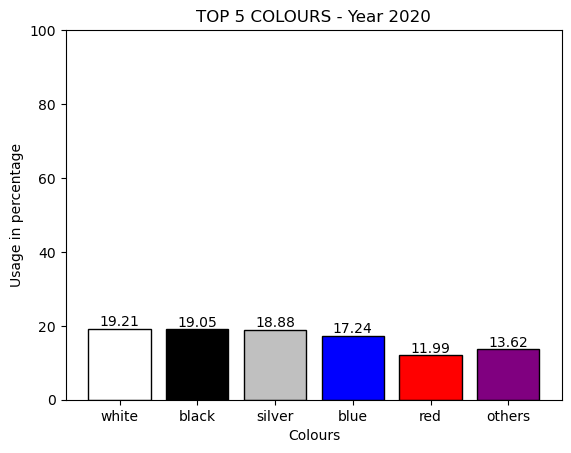

   COLOUR  COUNT (%)
0   white      19.21
1   black      19.05
2  silver      18.88
3    blue      17.24
4     red      11.99
5  others      13.62


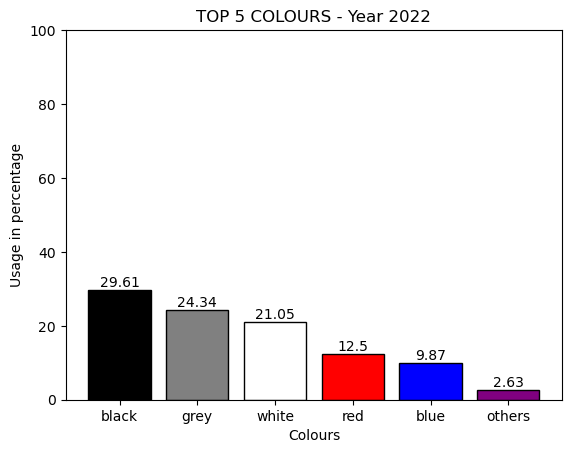

   COLOUR  COUNT (%)
0   black      29.61
1    grey      24.34
2   white      21.05
3     red      12.50
4    blue       9.87
5  others       2.63


In [18]:
# Plot annual chart to find the top 5 colours

# Year 2020
working_data_2020_summary = pandas.DataFrame([])
working_data_2020_summary = get_top_five_annual(working_data_2020)

# Year 2022
working_data_2022_summary = pandas.DataFrame([])
working_data_2022_summary = get_top_five_annual(working_data_2022)

# Create bar chart to show the result of each year
chart_2020 = plot_top_five_annual_bar_chart(working_data_2020_summary, 'TOP 5 COLOURS - Year 2020')
print(working_data_2020_summary)
chart_2022 = plot_top_five_annual_bar_chart(working_data_2022_summary, 'TOP 5 COLOURS - Year 2022')
print(working_data_2022_summary)


<b>Chart 2: Compare top 5 car colours with 2017 data from BBC News</b>

Plotting data from 3 years together, separated by ranking place, to compare the usage percentage of each place by ignoring the colours.

As per below chart, the overview of 2022 chart is quite different from 2017 and 2020 as the number of usage percentage in each ranking place are reduced respectively which shows that most people likely to have the same preferences, not widely expanded to other colours. In contrary, the overview of 2017 and 2020 charts are similar in the first 4 ranking places that there is no outstanding colour had been chosen by them. The usage of the top 3 colours in these 2 years are almost in the same level, while the 4th colour is slightly less than the first 3 colours. Apart from that, the 'others' colour also emphasizes that the favourite colour in each person from 2017 and 2020 had more varieties than 2022.

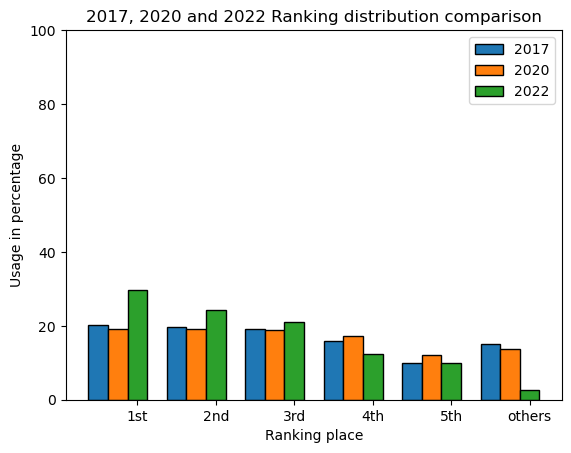

2017 Top 5 colours
   COLOUR  COUNT (%)
0   black       20.3
1    grey       19.7
2   white       19.0
3    blue       16.0
4  silver       10.0
5  others       15.0
2020 Top 5 colours
   COLOUR  COUNT (%)
0   white      19.21
1   black      19.05
2  silver      18.88
3    blue      17.24
4     red      11.99
5  others      13.62
2022 Top 5 colours
   COLOUR  COUNT (%)
0   black      29.61
1    grey      24.34
2   white      21.05
3     red      12.50
4    blue       9.87
5  others       2.63


In [12]:
# Plot comparison chart to show the percentage of each ranking place between 3 years

# Retrieve values from BBC News
working_data_2017_summary = pandas.DataFrame(data = {'COLOUR': ['black', 'grey', 'white', 'blue', 'silver', 'others'], \
                                                     'COUNT (%)': [20.3, 19.7, 19, 16, 10, 15]})

# Declare values that will be used in x
ranking_place = ['1st','2nd','3rd','4th','5th', 'others']
middle_bar = numpy.arange(6)
width = 0.25

# Plot the chart in format of 3 bars in parallel to compare 3 years data
comparison_chart = matplotlib.pyplot.bar(middle_bar-width, working_data_2017_summary['COUNT (%)'], align='center', width=width, tick_label=ranking_place, edgecolor='black')
comparison_chart = matplotlib.pyplot.bar(middle_bar, working_data_2020_summary['COUNT (%)'], align='center', width=width, tick_label=ranking_place, edgecolor='black')
comparison_chart = matplotlib.pyplot.bar(middle_bar+width, working_data_2022_summary['COUNT (%)'], align='center', width=width, tick_label=ranking_place, edgecolor='black')

# Set y to show from 0 to 100 as it is a percentage
matplotlib.pyplot.ylim(0,100)

# Show the information on the chart
matplotlib.pyplot.title('2017, 2020 and 2022 Ranking distribution comparison')
matplotlib.pyplot.xlabel('Ranking place')
matplotlib.pyplot.ylabel('Usage in percentage')
matplotlib.pyplot.legend(['2017', '2020', '2022'])

matplotlib.pyplot.show()
print('2017 Top 5 colours')
print(working_data_2017_summary)
print('====================')
print('2020 Top 5 colours')
print(working_data_2020_summary)
print('====================')
print('2022 Top 5 colours')
print(working_data_2022_summary)

#### (2) Finding on relationship between gender and car colour in 2022

<b>Chart 1: Show the proportion of colours used by each gender</b>

Using the above functions to plot pie charts to represent the proportion of each gender's favourite colours based on 2022 data.

From the charts below show that 1 out of 3 of female in this data collection prefers black colour which is a bigger proportion than male's propotion that only 1 out of 4 use black vehicles. However, it is interesting that the biggest proportion of male is white and the black and grey proportions are equal. On the other hand, proportion of the colourful vehicles in female is bigger than male.

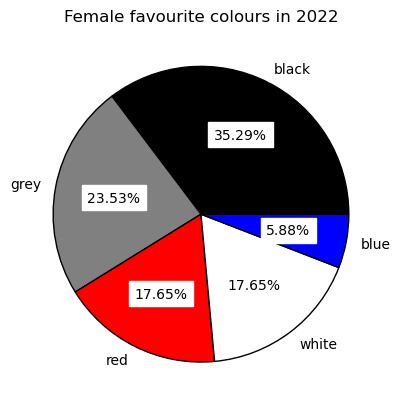

  DRIVER GENDER COLOUR  COUNT (%)
0        female  black      35.29
1        female   grey      23.53
2        female    red      17.65
3        female  white      17.65
4        female   blue       5.88


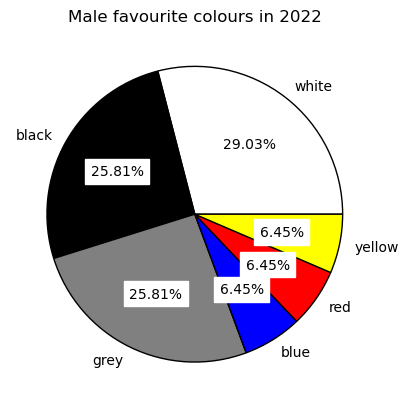

  DRIVER GENDER  COLOUR  COUNT (%)
0          male   white      29.03
1          male   black      25.81
2          male    grey      25.81
3          male    blue       6.45
4          male     red       6.45
5          male  yellow       6.45


In [13]:
# Plot chart separated by gender to see the proportions of each gender's favourite colours

# As mentioned in the note(2) at the beginning of the page that there's a limitation on this data collection 
# but it will be still processed to provide an idea on what we can analyse from it.

# Prepare data by droping the row that doesn't have either driver's gender or colour
working_data_2022_genderandcolour = working_data_2022.dropna(how = 'any')
working_data_2022_genderandcolour = working_data_2022_genderandcolour.reset_index(drop = True)

# Get percentage of each colour based on driver's gender
working_data_2022_female = get_colours_by_gender(working_data_2022_genderandcolour, 'female')
working_data_2022_male = get_colours_by_gender(working_data_2022_genderandcolour, 'male')

# Create pie chart to show the result
female_chart = plot_colours_by_genders_pie_chart(working_data_2022_female, 'Female')
print(working_data_2022_female)
male_chart = plot_colours_by_genders_pie_chart(working_data_2022_male, 'Male')
print(working_data_2022_male)

<b>Chart 2: Show the proportion of top ranked colour (black) used by each gender</b>

Plotting the pie chart to present the proportion of male and female that choose black vehicle.

As we can see, below chart shows that male is a bigger proportion to use black vehicle than female. Up to 57.14% of the black vehicles are used by male. However, this is a roughly estimate as this number comes from the data that the collectors collect both gender and vehicle colours only. If we would like to be more accurate on the number of proportions to compare back with the usage percentage of finding 1, we need to align on the collection form to collect on both colour and gender accordingly.

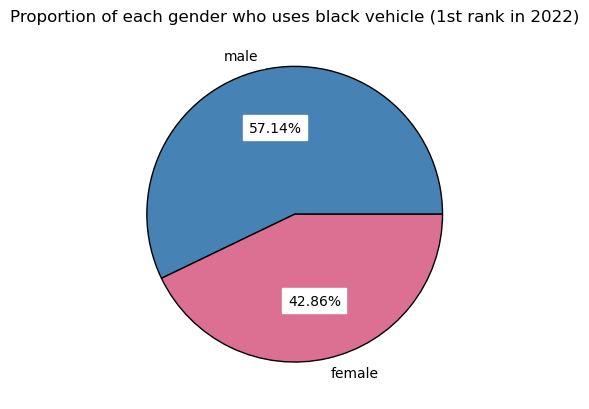

  DRIVER GENDER COLOUR  COUNT (%)
0          male  black      57.14
1        female  black      42.86


In [14]:
# Plot chart to see the proportion of genders in annual top colour (black).

# Filter data to get only the row with black colour
working_data_2022_blackcolour = working_data_2022_genderandcolour.loc[working_data_2022_genderandcolour['COLOUR'] == 'black']

# Get total number of data
total = len(working_data_2022_blackcolour)

# Count numbers of each gender
working_data_2022_blackcolour = working_data_2022_blackcolour.groupby(['DRIVER GENDER', 'COLOUR'], as_index = False).count()
working_data_2022_blackcolour = working_data_2022_blackcolour.rename(columns = {'TYPE': 'COUNT (%)'})

# Calculate percentage
working_data_2022_blackcolour['COUNT (%)'] = round(working_data_2022_blackcolour['COUNT (%)'].apply(lambda x: (x*100/total)), 2)
working_data_2022_blackcolour = working_data_2022_blackcolour.sort_values(by = ['COUNT (%)'], ascending = False)

# Reset index
working_data_2022_blackcolour = working_data_2022_blackcolour.reset_index(drop = True)

# Plot pie chart
gender_chart = matplotlib.pyplot.pie(working_data_2022_blackcolour['COUNT (%)'], labels = working_data_2022_blackcolour['DRIVER GENDER'], \
                                         colors=[{'male': 'steelblue', 'female': 'palevioletred'}[key] for key in working_data_2022_blackcolour['DRIVER GENDER']], autopct = '%1.2f%%', \
                                         textprops={'color':'black', 'backgroundcolor': 'white'}, \
                                         wedgeprops={'linewidth' : 1, 'edgecolor' : 'black' })

# Show the information on the chart
matplotlib.pyplot.title('Proportion of each gender who uses black vehicle (1st rank in 2022)')

# Show the result
matplotlib.pyplot.show()
print(working_data_2022_blackcolour)